In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("./dataset/date_cafea_consum.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    100 non-null    int64 
 1   Varsta                100 non-null    int64 
 2   Sex                   100 non-null    object
 3   Tip_Localitate        100 non-null    object
 4   Tip_Cafea_Preferat    100 non-null    object
 5   Numar_Cani_Pe_Zi      100 non-null    int64 
 6   Ora_Consum_Dominanta  100 non-null    object
 7   Buget_Luna_MDL        100 non-null    int64 
 8   Loc_Achizitie         100 non-null    object
dtypes: int64(4), object(5)
memory usage: 7.2+ KB


# Frecvente/ponderi

In [4]:
# Dupa frecventa consumului (cani/zi grupate)
freq_abs = df["Numar_Cani_Pe_Zi"].value_counts().sort_index()
freq_abs

Numar_Cani_Pe_Zi
1    18
2    41
3    30
4     7
5     4
Name: count, dtype: int64

In [5]:
freq_table = pd.DataFrame({
    "Frecventa": df["Numar_Cani_Pe_Zi"].value_counts().sort_index(),
    "Procent %": (df["Numar_Cani_Pe_Zi"].value_counts(normalize=True).sort_index() * 100).round(2)
})
print(freq_table)

                  Frecventa  Procent %
Numar_Cani_Pe_Zi                      
1                        18       18.0
2                        41       41.0
3                        30       30.0
4                         7        7.0
5                         4        4.0


In [6]:
print(freq_table.to_latex())

\begin{tabular}{lrr}
\toprule
 & Frecventa & Procent % \\
Numar_Cani_Pe_Zi &  &  \\
\midrule
1 & 18 & 18.000000 \\
2 & 41 & 41.000000 \\
3 & 30 & 30.000000 \\
4 & 7 & 7.000000 \\
5 & 4 & 4.000000 \\
\bottomrule
\end{tabular}



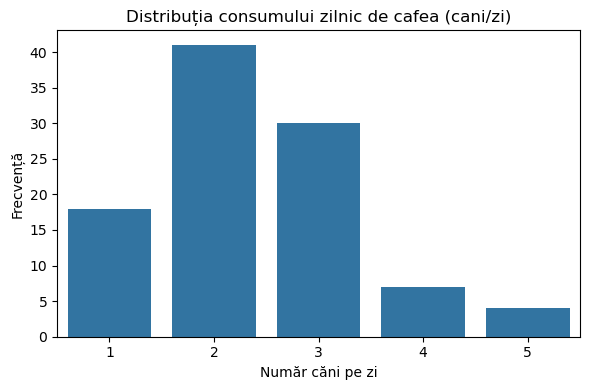

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Numar_Cani_Pe_Zi', data=df, order=sorted(df['Numar_Cani_Pe_Zi'].unique()))
plt.xlabel('Număr căni pe zi')
plt.ylabel('Frecvență')
plt.title('Distribuția consumului zilnic de cafea (cani/zi)')
plt.tight_layout()
plt.show()

In [8]:
freq_by_sex = (df.groupby(["Sex", "Numar_Cani_Pe_Zi"]).size().unstack(fill_value=0).sort_index(axis=1))
tbl = freq_by_sex.T
tbl = pd.concat([tbl, pd.DataFrame([tbl.sum(axis=0)], index=["Total"])], axis=0)
print(tbl)

Sex    Feminin  Masculin
1            9         9
2           21        20
3           14        16
4            5         2
5            2         2
Total       51        49


In [9]:
freq_by_sex_pct = (freq_by_sex.div(freq_by_sex.sum(axis=1), axis=0) * 100).round(2)
tbl = freq_by_sex_pct.T
tbl = pd.concat([tbl, pd.DataFrame([tbl.sum(axis=0)], index=["Total"])], axis=0)
print(tbl)

Sex    Feminin  Masculin
1        17.65     18.37
2        41.18     40.82
3        27.45     32.65
4         9.80      4.08
5         3.92      4.08
Total   100.00    100.00


In [10]:
freq_by_loc = (df.groupby(["Tip_Localitate", "Numar_Cani_Pe_Zi"]).size().unstack(fill_value=0).sort_index(axis=1))
freq_by_loc.T

Tip_Localitate,Rural,Urban
Numar_Cani_Pe_Zi,,
1,10,8
2,14,27
3,12,18
4,4,3
5,0,4


In [13]:
df.groupby(["Tip_Localitate", "Numar_Cani_Pe_Zi"]).size().unstack(fill_value=0)

Numar_Cani_Pe_Zi,1,2,3,4,5
Tip_Localitate,,,,,
Rural,10,14,12,4,0
Urban,8,27,18,3,4


In [26]:
res = df.groupby(["Tip_Localitate", "Numar_Cani_Pe_Zi"]).size().unstack(fill_value=0)

In [29]:
res.index

Index(['Rural', 'Urban'], dtype='object', name='Tip_Localitate')

In [30]:
res.columns

Index([1, 2, 3, 4, 5], dtype='int64', name='Numar_Cani_Pe_Zi')

In [31]:
res.to_numpy()

array([[10, 14, 12,  4,  0],
       [ 8, 27, 18,  3,  4]])

In [32]:
res.describe()

Numar_Cani_Pe_Zi,1,2,3,4,5
count,2.000000,2.000000,2.000000,2.000000,2.000000
mean,9.000000,20.500000,15.000000,3.500000,2.000000
std,1.414214,9.192388,4.242641,0.707107,2.828427
min,8.000000,14.000000,12.000000,3.000000,0.000000
25%,8.500000,17.250000,13.500000,3.250000,1.000000
50%,9.000000,20.500000,15.000000,3.500000,2.000000
75%,9.500000,23.750000,16.500000,3.750000,3.000000
max,10.000000,27.000000,18.000000,4.000000,4.000000


In [42]:
res.sort_index(axis=1, ascending=True)

Numar_Cani_Pe_Zi,1,2,3,4,5
Tip_Localitate,,,,,
Rural,10,14,12,4,0
Urban,8,27,18,3,4


In [48]:
res.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, Rural to Urban
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   1       2 non-null      int64
 1   2       2 non-null      int64
 2   3       2 non-null      int64
 3   4       2 non-null      int64
 4   5       2 non-null      int64
dtypes: int64(5)
memory usage: 96.0+ bytes


In [49]:
res[1]

Tip_Localitate
Rural    10
Urban     8
Name: 1, dtype: int64

In [53]:
resT = res.T

In [54]:
resT["Rural"]

Numar_Cani_Pe_Zi
1    10
2    14
3    12
4     4
5     0
Name: Rural, dtype: int64

In [55]:
resT.index

Index([1, 2, 3, 4, 5], dtype='int64', name='Numar_Cani_Pe_Zi')

In [56]:
resT.columns

Index(['Rural', 'Urban'], dtype='object', name='Tip_Localitate')

In [57]:
tmp = df.copy()

In [58]:
tmp.head()

,ID,Varsta,Sex,Tip_Localitate,Tip_Cafea_Preferat,Numar_Cani_Pe_Zi,Ora_Consum_Dominanta,Buget_Luna_MDL,Loc_Achizitie
0,1,18,Feminin,Urban,Latte,5,Dimineata,796,Supermarket
1,2,42,Feminin,Rural,Americano,2,Dimineata,497,Oficiu
2,3,60,Masculin,Rural,Decaf,4,Seara,1151,Oficiu
3,4,57,Feminin,Urban,Cappucino,3,Dimineata,276,Supermarket
4,5,59,Masculin,Rural,Latte,3,Pranz,1307,Supermarket


In [66]:
tmp[["Buget_Luna_MDL", "Varsta", "Numar_Cani_Pe_Zi"]].describe()

,Buget_Luna_MDL,Varsta,Numar_Cani_Pe_Zi
count,100.00000,100.000000,100.000000
mean,1296.73000,44.650000,2.380000
std,526.75327,13.980777,0.992701
min,265.00000,18.000000,1.000000
25%,950.25000,33.750000,2.000000
50%,1319.00000,43.000000,2.000000
75%,1681.50000,56.250000,3.000000
max,2420.00000,69.000000,5.000000


In [67]:
tmp.groupby("Sex")["Numar_Cani_Pe_Zi"].sum()

Sex
Feminin     123
Masculin    115
Name: Numar_Cani_Pe_Zi, dtype: int64

In [80]:
res = tmp.groupby(["Sex", "Numar_Cani_Pe_Zi"])

In [93]:
res["Varsta"].size().unstack()

Numar_Cani_Pe_Zi,1,2,3,4,5
Sex,,,,,
Feminin,9,21,14,5,2
Masculin,9,20,16,2,2


In [102]:
res["Varsta"].agg(["mean", "min", "max"])

mean  min  max
Sex      Numar_Cani_Pe_Zi                     
Feminin  1                 44.333333   23   61
         2                 40.000000   24   69
         3                 41.500000   21   65
         4                 55.400000   38   67
         5                 33.000000   18   48
Masculin 1                 43.000000   25   62
         2                 45.750000   20   66
         3                 50.187500   24   68
         4                 63.000000   60   66
         5                 35.500000   20   51

In [103]:
tmp = df.copy()

In [104]:
tmp["Tip_Cafea_Preferat"] = tmp["Tip_Cafea_Preferat"].astype("category")

In [105]:
tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   ID                    100 non-null    int64   
 1   Varsta                100 non-null    int64   
 2   Sex                   100 non-null    object  
 3   Tip_Localitate        100 non-null    object  
 4   Tip_Cafea_Preferat    100 non-null    category
 5   Numar_Cani_Pe_Zi      100 non-null    int64   
 6   Ora_Consum_Dominanta  100 non-null    object  
 7   Buget_Luna_MDL        100 non-null    int64   
 8   Loc_Achizitie         100 non-null    object  
dtypes: category(1), int64(4), object(4)
memory usage: 6.7+ KB


<Axes: >

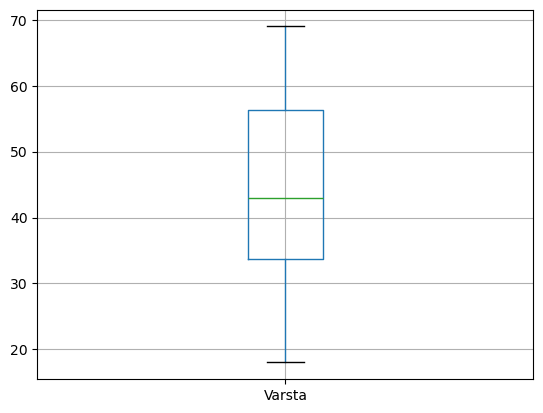

In [109]:
tmp.boxplot(column=["Varsta"])

In [126]:
tmp.groupby(["Sex", "Tip_Cafea_Preferat"], observed=True).size().unstack(fill_value=0)

Tip_Cafea_Preferat,Americano,Cappucino,Decaf,Espresso,Latte
Sex,,,,,
Feminin,15,6,10,10,10
Masculin,15,4,7,13,10
